# ResNet-18 Quantisation Sweep — Analysis

In [2]:
import sys
sys.path.insert(0, "../src")  # adjust if needed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import load_runs, flatten_runs

runs = load_runs('../runs', status='ok')
df   = pd.DataFrame(flatten_runs(runs))

df['backend']    = df['cfg.backend']
df['precision']  = df['cfg.model_precision']
df['input_bits'] = df['cfg.input_quant_bits'].fillna(0).astype(int)
df['top1']       = df['res.top1_acc']
df['top5']       = df['res.top5_acc']
df['lat_ms']     = df['res.infer_ms_avg']
df['tput']       = df['res.throughput_infer_sps']

print(f'{len(df)} runs loaded')
df[['backend','precision','input_bits','top1','top5','lat_ms','tput']].sort_values(['backend','precision','input_bits'])

32 runs loaded


,backend,precision,input_bits,top1,top5,lat_ms,tput
0,pytorch,fp16,1,0.8,4.6,3.045648,328.337384
1,pytorch,fp16,2,35.2,55.7,2.990681,334.372054
2,pytorch,fp16,4,83.5,94.9,3.018400,331.301398
3,pytorch,fp16,8,84.9,95.9,3.102972,322.271700
4,pytorch,fp32,1,0.8,4.6,2.951808,338.775472
5,pytorch,fp32,2,35.2,55.6,2.815437,355.184685
6,pytorch,fp32,4,83.6,94.9,2.829493,353.420174
7,pytorch,fp32,8,84.8,95.9,2.832111,353.093486
8,tensorrt,fp16,1,0.8,4.7,0.490201,2039.978331
9,tensorrt,fp16,2,35.3,55.8,0.462740,2161.039019


## Plot 1 — Top-1 Accuracy by Precision (grouped by backend, faceted by input_bits)

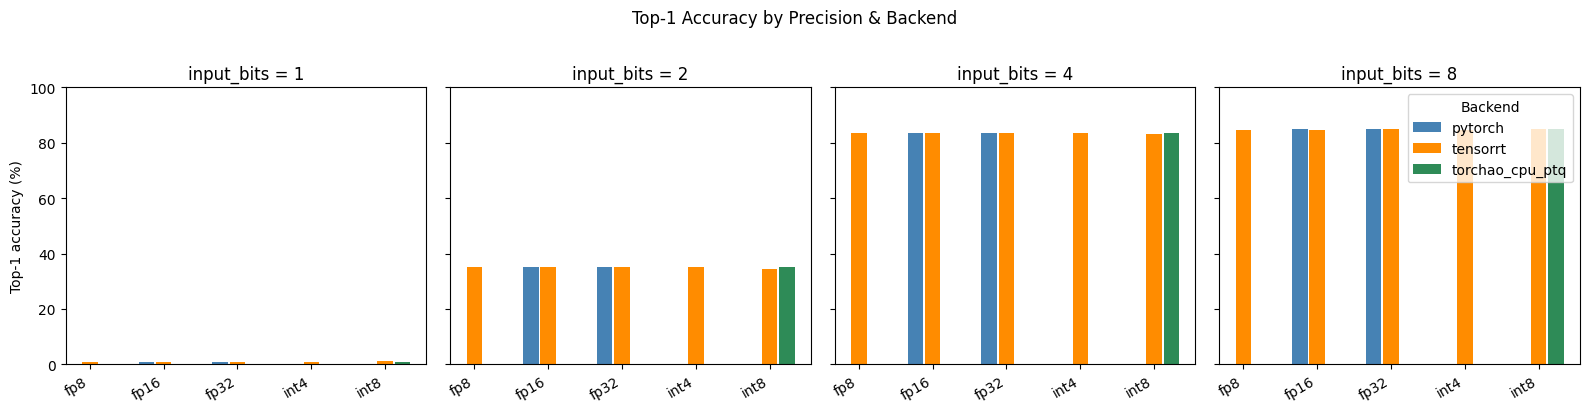

In [3]:
PRECISION_ORDER = ['fp8', 'fp16', 'fp32', 'int4', 'int8']
INPUT_BITS_LIST = sorted(df['input_bits'].unique())
BACKENDS        = sorted(df['backend'].unique())
COLORS          = ['steelblue', 'darkorange', 'seagreen']

n      = len(INPUT_BITS_LIST)
bar_w  = 0.7 / len(BACKENDS)
x      = np.arange(len(PRECISION_ORDER))

fig, axes = plt.subplots(1, n, figsize=(4*n, 4), sharey=True)
if n == 1: axes = [axes]

for ax, bits in zip(axes, INPUT_BITS_LIST):
    sub = df[df['input_bits'] == bits]
    for i, (backend, color) in enumerate(zip(BACKENDS, COLORS)):
        bdf = sub[sub['backend'] == backend].set_index('precision')
        ys  = [bdf.loc[p, 'top1'] if p in bdf.index else np.nan for p in PRECISION_ORDER]
        ax.bar(x + i*bar_w - (len(BACKENDS)-1)*bar_w/2, ys, width=bar_w*0.9,
               color=color, label=backend)
    ax.set_title(f'input_bits = {bits}')
    ax.set_xticks(x)
    ax.set_xticklabels(PRECISION_ORDER, rotation=30, ha='right')
    ax.set_ylim(0, 100)

axes[0].set_ylabel('Top-1 accuracy (%)')
axes[-1].legend(title='Backend')
fig.suptitle('Top-1 Accuracy by Precision & Backend', y=1.02)
plt.tight_layout()
plt.savefig('../runs/plot1_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 2 — Accuracy vs Latency (scatter)

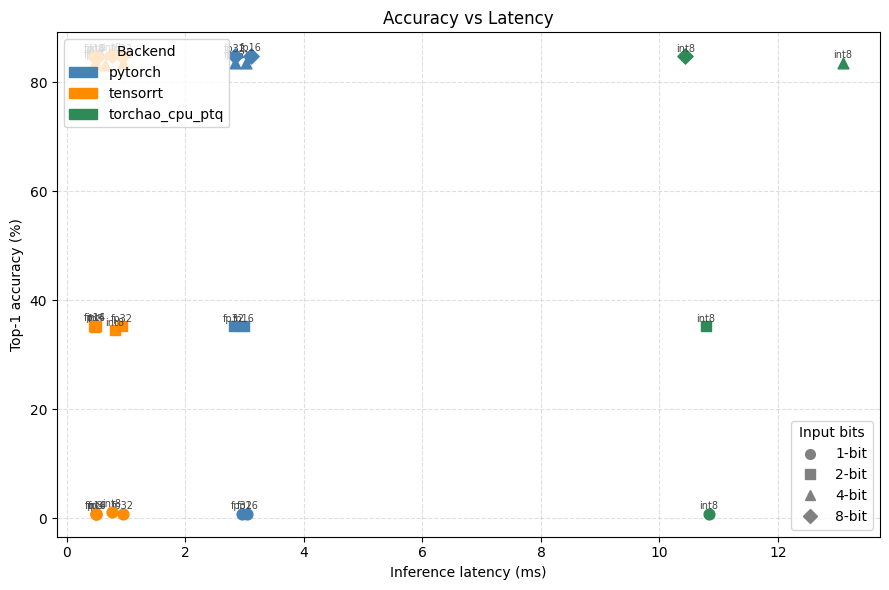

In [4]:
MARKERS = {1: 'o', 2: 's', 4: '^', 8: 'D'}

fig, ax = plt.subplots(figsize=(9, 6))

for (backend, bits), grp in df.groupby(['backend', 'input_bits']):
    color  = COLORS[BACKENDS.index(backend)]
    marker = MARKERS.get(bits, 'o')
    for _, row in grp.iterrows():
        ax.scatter(row['lat_ms'], row['top1'], color=color, marker=marker,
                   s=60, zorder=3)
        ax.text(row['lat_ms'], row['top1'] + 0.5, row['precision'],
                fontsize=7, ha='center', va='bottom', color='#444')

# Legends
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
color_leg = [mpatches.Patch(color=c, label=b) for b, c in zip(BACKENDS, COLORS)]
marker_leg = [Line2D([0],[0], marker=MARKERS.get(b,'o'), color='gray',
                      linestyle='None', markersize=7, label=f'{b}-bit') for b in sorted(MARKERS)]
l1 = ax.legend(handles=color_leg,  title='Backend',    loc='upper left')
ax.legend(handles=marker_leg, title='Input bits', loc='lower right')
ax.add_artist(l1)

ax.set_xlabel('Inference latency (ms)')
ax.set_ylabel('Top-1 accuracy (%)')
ax.set_title('Accuracy vs Latency')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../runs/plot2_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 3 — Accuracy vs Input Bits

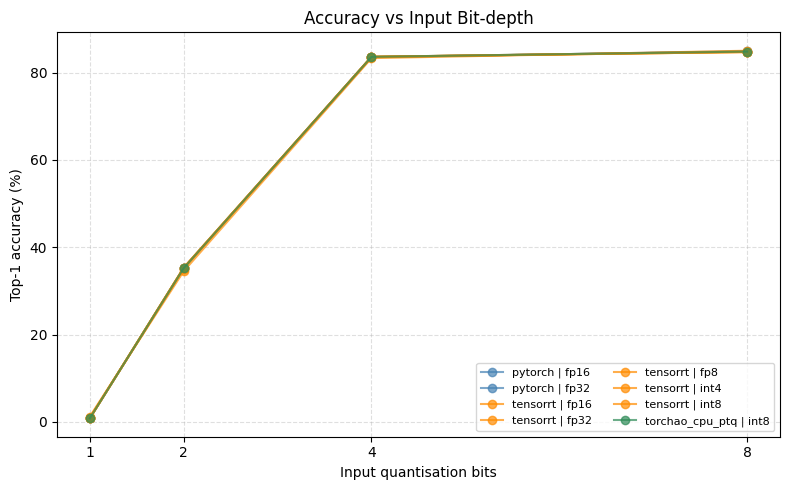

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

for (backend, prec), grp in df.groupby(['backend', 'precision']):
    color = COLORS[BACKENDS.index(backend)]
    grp   = grp.sort_values('input_bits')
    ax.plot(grp['input_bits'], grp['top1'], marker='o', color=color,
            alpha=0.7, linewidth=1.5, label=f'{backend} | {prec}')

ax.set_xlabel('Input quantisation bits')
ax.set_ylabel('Top-1 accuracy (%)')
ax.set_title('Accuracy vs Input Bit-depth')
ax.set_xticks(INPUT_BITS_LIST)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('../runs/plot3_acc_vs_bits.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 4 — Inference by Run

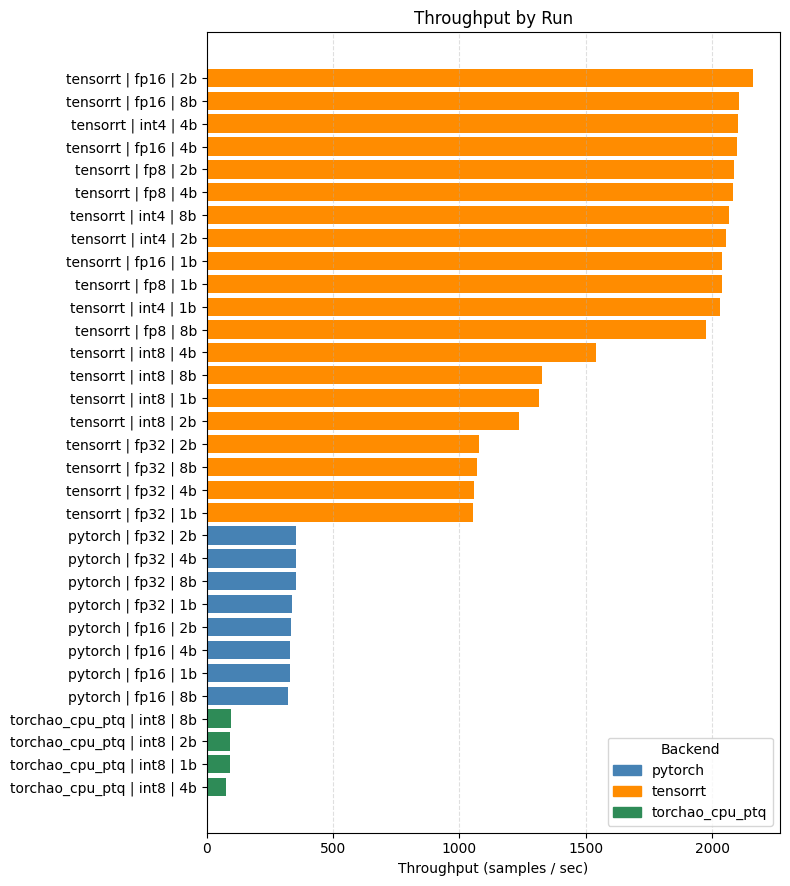

In [6]:
tput = (
    df.dropna(subset=['tput'])
    .assign(label=lambda x: x['backend'] + ' | ' + x['precision'] + ' | ' + x['input_bits'].astype(str) + 'b')
    .sort_values('tput', ascending=True)
)

fig, ax = plt.subplots(figsize=(8, max(5, len(tput)*0.28)))

colors = [COLORS[BACKENDS.index(b)] for b in tput['backend']]
ax.barh(tput['label'], tput['tput'], color=colors)

ax.set_xlabel('Throughput (samples / sec)')
ax.set_title('Throughput by Run')
ax.grid(axis='x', linestyle='--', alpha=0.4)

legend_h = [mpatches.Patch(color=c, label=b) for b, c in zip(BACKENDS, COLORS)]
ax.legend(handles=legend_h, title='Backend')
plt.tight_layout()
plt.savefig('../runs/plot4_throughput.png', dpi=150, bbox_inches='tight')
plt.show()